In [ ]:
import mne
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
edf_path = r'D:\2025_26_internship\bigP3BCI_pipeline\Data\StudyA\A_01\SE001\Train\CB\A_01_SE001_CB_Train01.edf'


# Load the EDF file
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
target_channel = "EEG_Cz"

# Use .filter to remove slow drifts and DC offset at low frequencies
# and muscle/noise artifacts at high frequencies
raw.filter(l_freq=0.5, h_freq=45.0)


picks = mne.pick_channels(raw.ch_names, [target_channel])

spectrum = raw.compute_psd(method="welch", picks=picks)

# Extract PSD values and corresponding frequencies
psds = spectrum.get_data(fmin=0.5, fmax=50.0).flatten() # Flatten to 1D array for single channel
freqs = spectrum.freqs

Effective window size : 8.000 (s)


C:\Users\qigan\AppData\Local\Temp\ipykernel_20248\3925288314.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\qigan\AppData\Local\Temp\ipykernel_20248\3925288314.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Plotting power spectral density (dB=True).


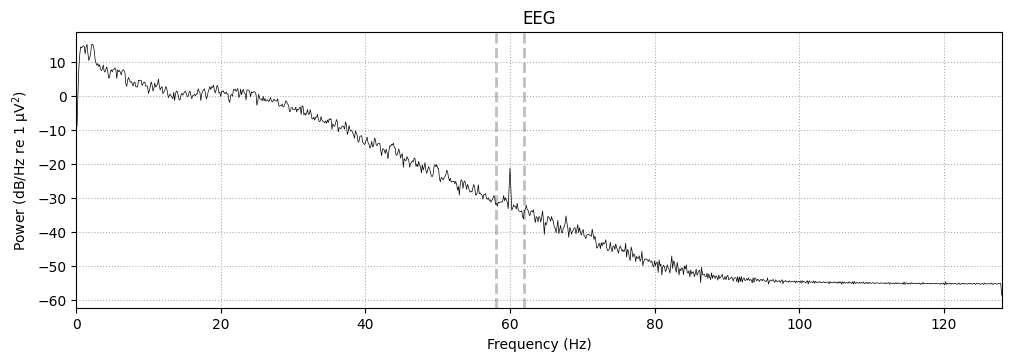

In [13]:
# --- 6. Plot the Power Spectrum ---
# The Spectrum object has a built-in plot method for convenience
spectrum.plot(
    average=True,            # Average over time segments
    dB=True,                 # Plot in decibels (10*log10(Power))
    show=False               # Don't show immediately for customization
)

